In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

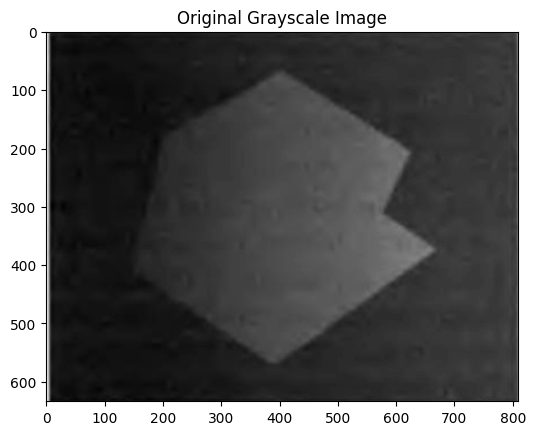

In [12]:
original_image = cv2.imread("adaptive_thresholding.jpg", 0)

plt.imshow(original_image, cmap='gray')
plt.title("Original Grayscale Image")

plt.show()


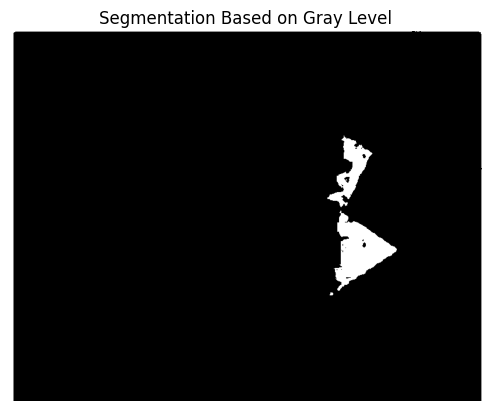

In [13]:
# Simple threshold value
threshold = 127

# Create output image array
segmented = np.zeros_like(original_image)

# Apply threshold manually using loops
rows, cols = original_image.shape
for i in range(rows):
    for j in range(cols):
        if original_image[i, j] > threshold:
            segmented[i, j] = 255
        else:
            segmented[i, j] = 0

plt.imshow(segmented, cmap='gray')
plt.title("Segmentation Based on Gray Level")
plt.axis('off')
plt.show()


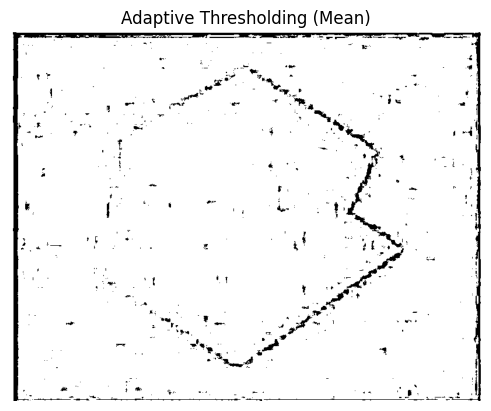

In [14]:
# Define window size (should be odd)
window_size = 11
C = 2

# Padding size
pad = window_size // 2
padded_image = np.pad(original_image, pad, mode='reflect')

adaptive_segmented = np.zeros_like(original_image)

for i in range(rows):
    for j in range(cols):
        # Extract local window
        local_window = padded_image[i:i+window_size, j:j+window_size]
        local_mean = np.mean(local_window)
        
        if original_image[i, j] > local_mean - C:
            adaptive_segmented[i, j] = 255
        else:
            adaptive_segmented[i, j] = 0

plt.imshow(adaptive_segmented, cmap='gray')
plt.title("Adaptive Thresholding (Mean)")
plt.axis('off')
plt.show()
